# c. Avatar (Movie) Network: Undirected, Weighted
## Dataset Description

| Property | Details |
|----------|---------|
| **Nodes** | Characters in the movie |
| **Edges** | Co-appearance in the same scene between two characters |
| **Weight** | Number of shared scene appearances |
| **Type** | Undirected, Weighted |

*Source: J. Kaminski et al., "Moviegalaxies - Social Networks in Movies." https://doi.org/10.7910/DVN/T4HBA3, Harvard Dataverse, V3 (2018)*


## 1. Data Loading
We load the two CSV files containing the network data: `nodes.csv` (characters) and `edges.csv` (co-appearance links).


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT/"data"

nodes_path = DATA_DIR/"nodes.csv"
edges_path = DATA_DIR/"edges.csv"

nodes = pd.read_csv(nodes_path)
edges = pd.read_csv(edges_path)


## 2. Data Exploration

### 2.1 Nodes
Analysing the table of nodes to understand how characters are presented.


In [3]:
nodes.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        30 non-null     int64
 1   Label     30 non-null     str  
 2   movie_id  30 non-null     int64
dtypes: int64(2), str(1)
memory usage: 852.0 bytes


In [4]:
nodes.head()

,Id,Label,movie_id
0,519631,JAKE,88
1,520100,QUARITCH,88
2,520425,SELFRIDGE,88
3,520314,GRACE,88
4,520156,NORM,88


The nodes table contains **30 characters**, each described by:
- `Id`: unique numeric identifier
- `Label`: character name (JAKE, QUARITCH, GRACE)
- `movie_id`:movie identifier (88 = Avatar)

There are **no missing values**, therefore the data is ready to be used directly. 

### 2.2 Edges
Furthermore, we inspect the edges table to understand how co-appearances are recorded.

In [5]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Source    105 non-null    int64
 1   Target    105 non-null    int64
 2   Type      105 non-null    str  
 3   Id        105 non-null    int64
 4   Label     105 non-null    int64
 5   Weight    105 non-null    int64
 6   movie_id  105 non-null    int64
dtypes: int64(6), str(1)
memory usage: 5.9 KB


In [6]:
edges.head()

,Source,Target,Type,Id,Label,Weight,movie_id
0,519777,519783,Undirected,0,17872,1,88
1,519965,519631,Undirected,1,17876,1,88
2,519965,520084,Undirected,2,17877,1,88
3,519965,520010,Undirected,3,17875,1,88
4,522131,520314,Undirected,4,18043,1,88


The edge table contains **105 co-appearance connections** between characters. 

Key observations:
- All edges are `undirected`: if character A shares a scene with B, the same is true for the opposite (A ⭤ B)
- The `Weight` column counts **how many scenes** two characters shared: a higher weight indicates a stronger relationship
- The `Label` column is a numerical identifier of the edge and can be ignored for analysis

This confirms that we are working with an **undirected, weighted network** of 30 nodes and 105 edges.

## Week 1

### Tasks
a) Pick a social network among the one proposed on luiss.learn

b) Implement it in Python.

c) Draw the graph

d) Compute the number of nodes,edges, average degree and the density. Comment.


### 1.1 Graph Building

We construct an undirected weighted graph using NetworkX. 

Each character becomes a **node** and each co-appearance becomes an **edge**, with the **weight** representing the number of shared scenes.


In [7]:
G = nx.Graph() # builds an empty undirected graph

# Add nodes with label attribute
for _, row in nodes.iterrows():
    G.add_node(row['Id'], label=row['Label'])

# Add edges with weight attribute
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

### 1.2 Graph Visualization

We visualize the network using a spring layout, where the thickness of the edges reflects the weight, the number of shared scenes between two characters.


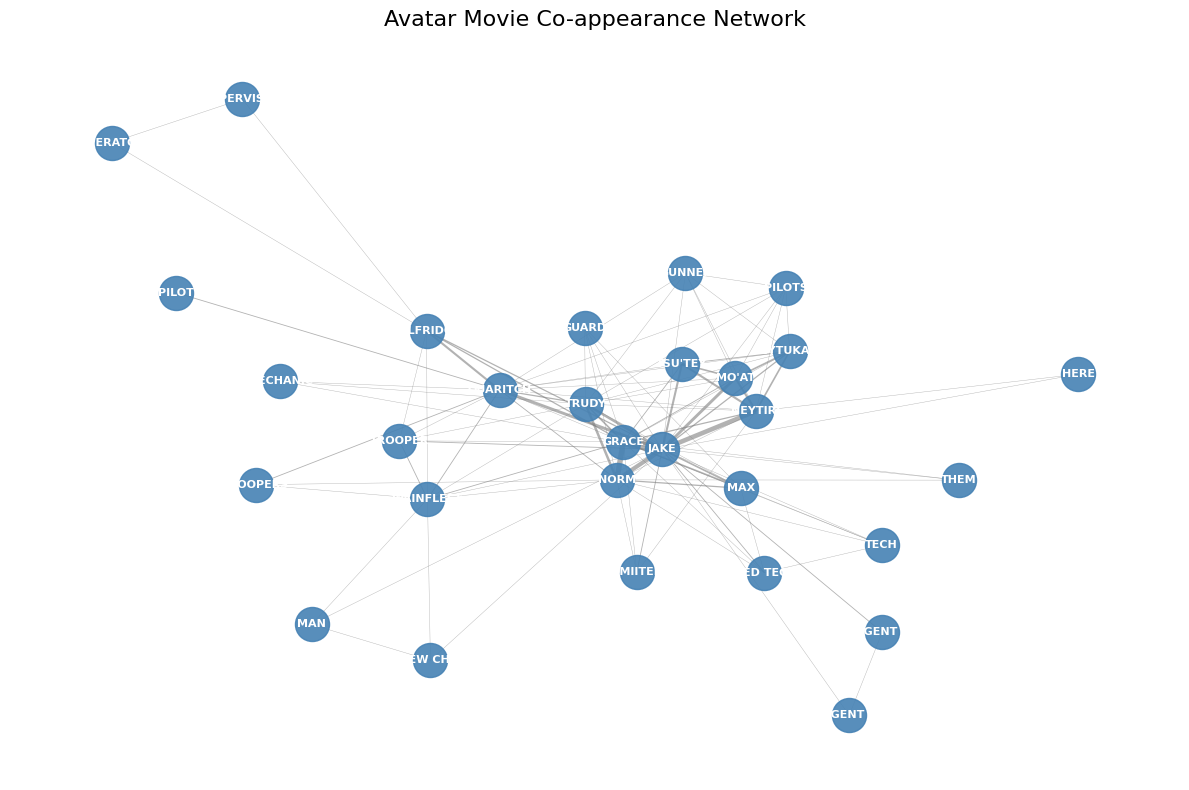

In [8]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=54)
labels = nx.get_node_attributes(G, 'label')
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=600, node_color='steelblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, width=[w * 0.3 for w in weights], alpha=0.6, edge_color='gray')

plt.title("Avatar Movie Co-appearance Network", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


### Graph Analysis:

- **JAKE, GRACE, NORM, TRUDY, NEYTIRI and QUARITCH** appear at the center of the network, with numerous connections to other characters, highlighting that they are the protagonists of the story.

- **JAKE** in particular sits at the very centre, with the thickest edges connecting him to NEYTIRI, GRACE and NORM, highlighting how many screen time he shares with them. 

- The **peripheral nodes** (PILOT, ERVIS, HERE, THEM) have very few connections and represent minor or secondary characters who interact only briefly with the main cast.

- The network has a clear **hub-and-spoke structure**: a dense core of main characters surrounded by more loosely connected secondary characters


### 1.3 Basic Network Statistics

We now compute the key structural metrics of the network.

In [9]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)

print(f"Number of nodes  : {num_nodes}")
print(f"Number of edges  : {num_edges}")
print(f"Average degree   : {avg_degree:.4f}")
print(f"Density          : {density:.4f}")


Number of nodes  : 30
Number of edges  : 105
Average degree   : 7.0000
Density          : 0.2414


### **Interpretation:**

The Avatar cast network consists of **30 nodes** and **105 edges**, with an average degree of **7.0**, meaning that each character shares scenes with 7 others on average.
  
This is a relatively high value for a network of 30 nodes, indicating a well-connected cast in which interactions are spread across many character pairs rather than concentrated on a few.

The network density is **0.2414**, meaning that only about 24% of all possible connections actually exist.
This moderate sparseness is consistent with the plot, as the film is structured around two distinct social worlds.
Between the **military/human group** (Jake, Quaritch, Grace, Norm, Trudy) and the **Na'vi clan** (Neytiri, Mo'at, Tsu'tey), who interact intensely within each group, but only through a few key characters who act as bridges between the groups. 
**Jake**, for example, serves as the main bridge, belonging to both worlds throughout the story.

A fully connected network of 30 nodes would require 435 edges, but we only have 105, which confirms that the interactions between the characters are selective and structured rather than random.

## Week 2

### Tasks
While considering the largest component of your network.

a) Design a function computing the clusering at every nodes and another on that computes the average clustering.

b) Compare to inbuild function Compute Average clustering and Transitivity number,


### 2.1 Clustering Coefficient


#### Clustering Coefficient of Node $i$

The **local clustering coefficient** of node $i$ is defined as the ratio of pairs of friends of $i$ that are also friends with each other:

$$C(i) := \frac{\text{Number of triangles where } i \text{ participates}}{k_i(k_i - 1)/2}$$

where $k_i$ is the degree of node $i$ and $k_i(k_i-1)/2$ is the number of **wedges** (pairs of friends) around $i$. By convention, $C(i) = 0$ if $i$ has fewer than 2 neighbors.



#### Average Clustering

To compare across graphs, we average the local clustering coefficients over all nodes:

$$\langle C \rangle = \frac{1}{N} \sum_{i \in V} C(i)$$



#### Transitivity

Rather than averaging locally, transitivity counts triangles **globally** and normalises by the total number of wedges:

$$T(G) := \frac{\text{Number of triangles in the network}}{\sum_i k_i(k_i-1)/2 \ / \ 3}= \frac{3 \times \text{Number of triangles}}{\sum_i k_i(k_i-1)/2}$$

We divide the number of wedges by **3** because each triangle is counted once for each of its 3 nodes.


In [10]:
def clustering(G):
    clusters = dict()
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        
        if degree <= 2: # if the degree is 2 we cannot have any cluster
            clusters[node] = 0.0
            continue
            
        triangles = sum(1 for i in range(degree) 
                          for j in range(i+1, degree) 
                          if G.has_edge(neighbors[i], neighbors[j]))
        local_wedges = degree * (degree - 1) / 2
        
        clusters[node] = triangles / local_wedges
        
    return clusters

In [11]:
def clustering(G): 
    clusters = dict()
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        
        if degree < 2: #need at least 2 neighbors to form a triangle 
            clusters[node] = 0.0
            continue
            
        triangles = sum(1 for i in range(degree) for j in range(i+1, degree) if G.has_edge(neighbors[i], neighbors[j])) 
        local_wages = degree * (degree - 1) / 2 
        
        clusters[node] = triangles / local_wages
        
    return clusters

In [12]:
def average_clustering(G):
    c = clustering(G)
    return sum(c.values()) / len(c)

In [13]:
# My clustering
my_clustering = clustering(G)
my_avg = average_clustering(G)

# NetworkX built-ins
nx_clustering = nx.clustering(G)
nx_avg = nx.average_clustering(G)
nx_transitivity = nx.transitivity(G)

print(f"Custom average clustering   : {my_avg:.6f}")
print(f"NetworkX average clustering : {nx_avg:.6f}")
print(f"NetworkX transitivity       : {nx_transitivity:.6f}")


Custom average clustering   : 0.804295
NetworkX average clustering : 0.804295
NetworkX transitivity       : 0.500928


### **Interpretation:**

- The **average clustering of 0.80** is very high, meaning that 80% of a character's co-stars also act together.
This shows that characters from the same group (like a military team or Na'vi clan) often appear together, forming many small groups.

- **Transitivity (0.50)** is lower because it is a *global* measure that weights nodes by their number of wedges. 

- **High-degree hub** characters like **JAKE and GRACE** generate many wedges but not all of them close into triangles, as they bridge the two social worlds of the film (human vs. Na'vi), connecting groups that don't always interact with each other directly.

- The gap between **average clustering (0.80)** and **transitivity (0.50)** is a signature of a **hub-and-spoke structure**: there are close local groups, but the connections between them lower the overall number of groups.


## Week 3 


### Tasks
a) Compute the cumulative distribution of the clustering coefficients

b) For every node, compute the average clustering of its neighbors

c) Compare the two distributions



### 3.1 CDF of Node Clustering Coefficients

We use the **Cumulative Distribution Function (CDF)** instead of a histogram to show the distribution of clustering values because clustering is a continuous value. 

This choice helps avoid random bin selections and provides a clearer view of how clustering values are spread out across nodes.


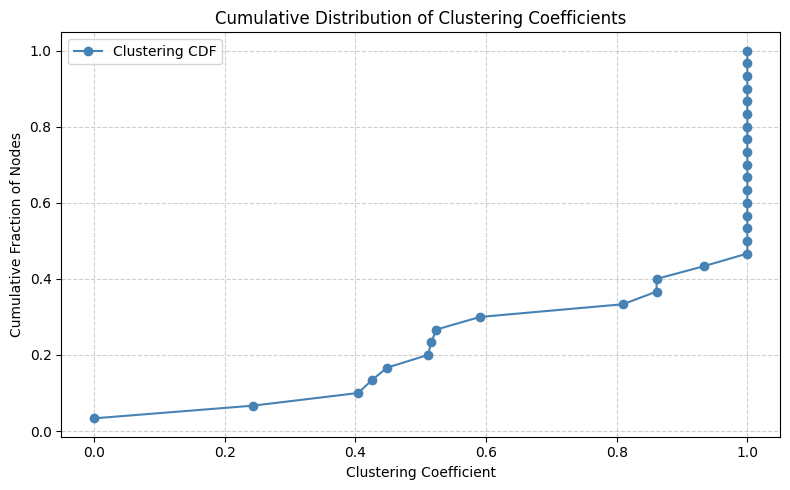

In [14]:
import numpy as np

# Get clustering values sorted
clust_values = sorted(my_clustering.values())
cdf = np.arange(1, len(clust_values) + 1) / len(clust_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label='Clustering CDF')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title('Cumulative Distribution of Clustering Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Graph Analysis

The CDF shows that the distribution is **heavily skewed towards high values**: roughly 50% of nodes have a clustering coefficient of exactly 1.0. This means that half of the characters are in groups where all their co-stars also work together.

Only a few nodes (those with clustering near 0) are isolated connectors with no triangles around them. These are minor characters who appear briefly with the main cast but whose connections don’t meet each other.


### 3.2 Average Neighbor Clustering

For each node, we compute the **average clustering coefficient of its neighbors**, this tells us whether a character's co-stars tend to be tightly embedded in groups themselves.


In [15]:
def avg_neighbor_clustering(G, clustering_dict):
    result = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        degree = len(neighbors)
        if degree == 0:
            result[node] = 0.0
        else:
            result[node] = np.mean([clustering_dict[n] for n in neighbors])
    return result

neighbor_avg_clust = avg_neighbor_clustering(G, my_clustering)


### 3.3 Comparing the Two Distributions


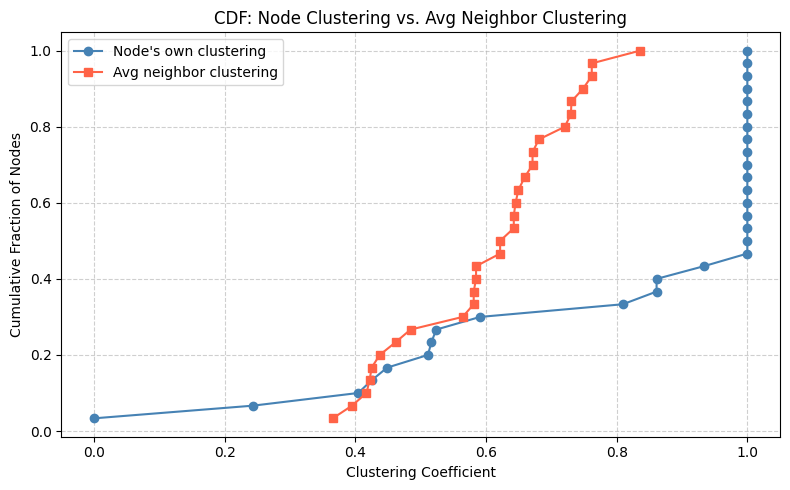

In [16]:
neigh_values = sorted(neighbor_avg_clust.values())
cdf_neigh = np.arange(1, len(neigh_values) + 1) / len(neigh_values)

plt.figure(figsize=(8, 5))
plt.plot(clust_values, cdf, marker='o', color='steelblue', label="Node's own clustering")
plt.plot(neigh_values, cdf_neigh, marker='s', color='tomato', label="Avg neighbor clustering")
plt.xlabel('Clustering Coefficient')
plt.ylabel('Cumulative Fraction of Nodes')
plt.title("CDF: Node Clustering vs. Avg Neighbor Clustering")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Graph Analysis 

- The **neighbor clustering CDF (red) shifts to the left** of the node clustering CDF (blue), meaning that on average, a character's neighbors tend to have *lower* clustering than the character itself. 

- This highlights **disassortative clustering**, where highly clustered nodes (tight group members) tend to be connected to nodes that are less clustered (hub characters who bridge groups). 

- Intuitively, this makes sense in Avatar: tightly knit peripheral groups (e.g. the Na'vi clan) connect to central hub characters like **JAKE**, who bridges multiple worlds and therefore has a lower clustering coefficient than the group members surrounding him

In social network terms: *your friends' social circles tend to be less tight than your own* the main characters spread out the connections of their neighborhoods.


## Week 5

### Tasks

1) Depending on what seems more relevant in your graph, pick two of the following local notions

    - Decay centrality
    - Betweeness centrality
    - Closeness centrality
    - Any other notions that you invent
    - Pagerank

2) Identify the most central nodes.

### Choice of Centrality Measures

There is no one clear meaning of “importance” in a network; it varies based on what we want to learn, like how information spreads, how infections move, influence, or how failures happen. So, we need to pick the best ways to measure based on what our network is like. In 

Avatar's co-appearance network, a link between two characters shows that they were in the same scene, so the network shows how close they are and how they interact in the story. Therefore, we focus on:


- **Betweenness centrality**: measures how important a node is in terms of *connecting other nodes*. 
In a co-appearance network, a character with high betweenness acts as a narrative bridge, without them, other characters would never interact. This is particularly important here because the film revolves *around two opposing factions* (human military vs. Na'vi), and we expect a few characters to connect both sides.

- **Closeness centrality**: measures how easily a node can *reach all other nodes*, defined as the **inverse of the average distance** to all others:
$$C^{clo}(i) = \frac{N-1}{\sum_{j \neq i} d(i,j)}$$
 A character with high closeness is very involved in the story and interacts with many others.

We do not use **degree centrality** as it only captures the raw number of connections without accounting for the network's structure, and **decay centrality** as it introduces a free parameter $\delta$ that would require additional justification to set. 

**PageRank** is designed for directed networks and is less natural here since co-appearances are symmetric.


### 5.1 Graph Preprocessing

We work on the **Largest Connected Component (LCC)** to ensure all distance-based metrics are well-defined, and set `inv_weight = 1/weight` as the distance attribute.


In [17]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
G_lcc.remove_edges_from(nx.selfloop_edges(G_lcc))

# Add inverse weight as distance attribute
for u, v, d in G_lcc.edges(data=True):
    d['inv_weight'] = 1 / d['weight']

betweenness = nx.betweenness_centrality(G_lcc, weight='inv_weight')
closeness   = nx.closeness_centrality(G_lcc, distance='inv_weight')


### 5.2 Most Central Nodes

In [18]:
df_centrality = pd.DataFrame({
    'Label'      : [G_lcc.nodes[n]['label'] for n in G_lcc.nodes()],
    'Betweenness': [betweenness[n] for n in G_lcc.nodes()],
    'Closeness'  : [closeness[n]   for n in G_lcc.nodes()]
})

df_centrality = df_centrality.sort_values('Betweenness', ascending=False).reset_index(drop=True)
print(df_centrality.to_string(index=False))


     Label  Betweenness  Closeness
      JAKE     0.736658   1.584044
  QUARITCH     0.172824   1.429379
 SELFRIDGE     0.133005   1.168066
     GRACE     0.067529   1.515022
   NEYTIRI     0.011084   1.429883
     TRUDY     0.005337   1.305861
      NORM     0.004721   1.416439
 WAINFLEET     0.002463   0.954434
       MAX     0.000616   1.174600
    PILOTS     0.000000   0.663652
   OMIITED     0.000000   0.897622
  OPERATOR     0.000000   0.559550
     PILOT     0.000000   0.845764
  TROOPERS     0.000000   0.845764
SUPERVISOR     0.000000   0.559550
      TECH     0.000000   0.639297
      THEM     0.000000   0.628899
  MECHANIC     0.000000   0.640676
  MED TECH     0.000000   0.911732
     GUARD     0.000000   0.634633
       MAN     0.000000   0.647901
      HERE     0.000000   0.628613
    GUNNER     0.000000   0.663652
CREW CHIEF     0.000000   0.647901
   AGENT 2     0.000000   0.633083
   AGENT 1     0.000000   0.911732
   TROOPER     0.000000   0.913099
     MO'AT     0.000

### Interpretation

**Betweenness centrality** highlights characters who act as structural bridges. 

**JAKE** dominates with a score of 0.737, far above everyone else, confirming his unique role as the connector between the human military and the Na'vi world. Without JAKE, the two factions would be almost entirely disconnected. 

**QUARITCH (0.173)** and **SELFRIDGE (0.133)** rank next, as they coordinate the human side and connect peripheral military characters to the core network.

**Closeness centrality** measures how quickly a character can reach everyone else in the network. 

**JAKE (1.584)** again leads, followed closely by **GRACE (1.515)** and **NEYTIRI (1.430)**, all three interact across multiple groups throughout the film. 

Peripheral characters such as **OPERATOR, SUPERVISOR, and GUARD** score below 0.65, as they appear in very few scenes and are structurally distant from the core.

The two metrics tell a consistent story: JAKE is both the most central *bridge* and the most *reachable* character, highlighting his role as the main character who exists between two worlds.

### 5.3 Visualization

The **size** of the nodes shows how much they connect others (bigger = more connections); the **color** of the nodes shows how close they are to all other nodes (greener = closer).


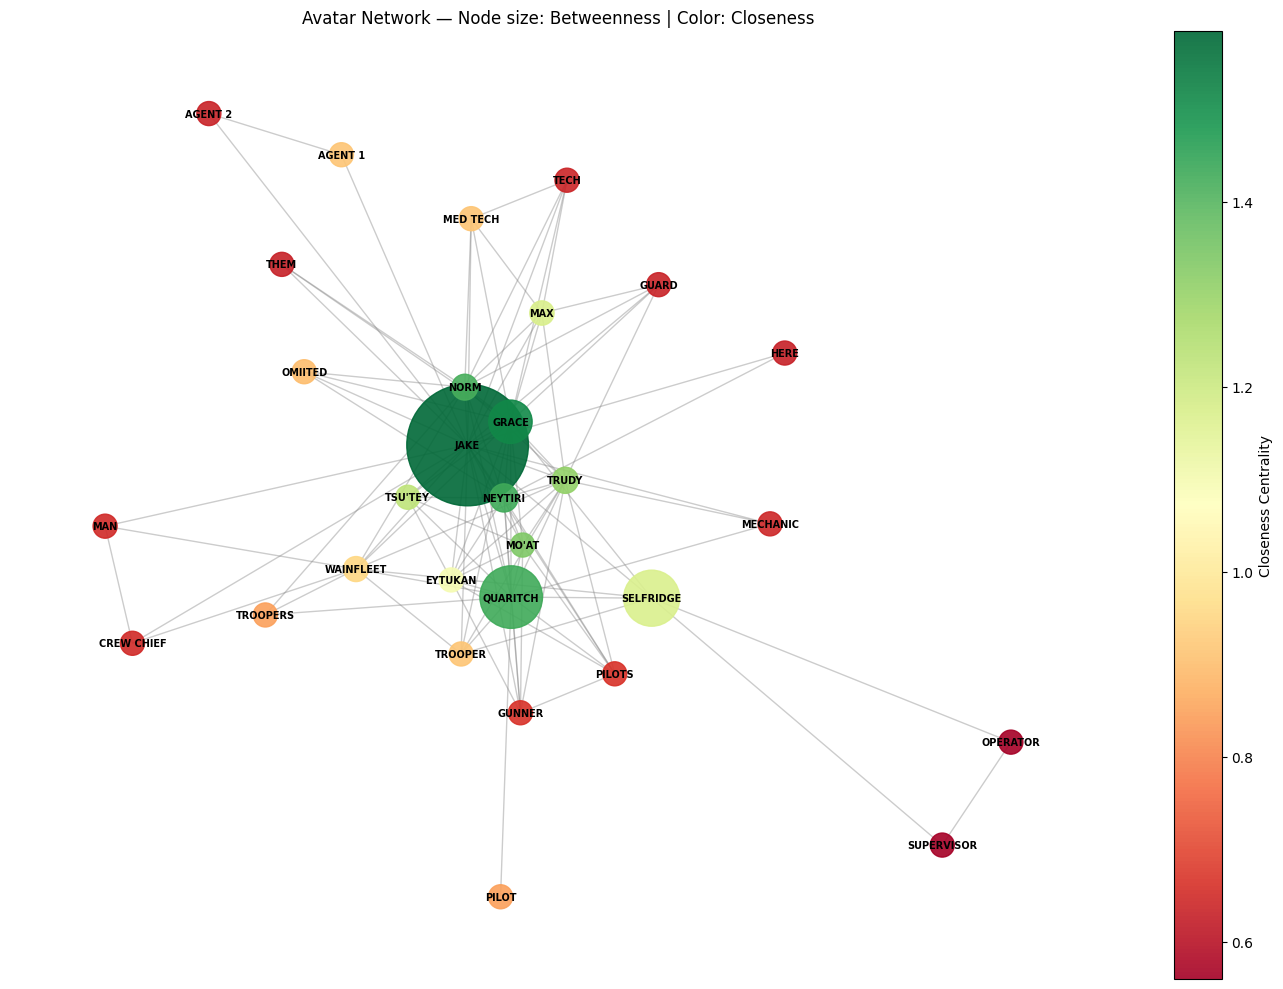

In [61]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_lcc, seed=42)
labels = nx.get_node_attributes(G_lcc, 'label')

node_size  = [betweenness[n] * 10000 + 300 for n in G_lcc.nodes()]
node_color = [closeness[n] for n in G_lcc.nodes()]

nx.draw_networkx_edges(G_lcc, pos, alpha=0.4, edge_color='gray')
nc = nx.draw_networkx_nodes(G_lcc, pos, node_size=node_size, node_color=node_color, cmap=plt.cm.RdYlGn, alpha=0.9)
nx.draw_networkx_labels(G_lcc, pos, labels=labels, font_size=7, font_color='black', font_weight='bold')

plt.colorbar(nc, label='Closeness Centrality')
plt.title("Avatar Network — Node size: Betweenness | Color: Closeness")
plt.axis('off')
plt.tight_layout()
plt.show()


The visualization confirms the quantitative results: 

- **JAKE** (betweenness: 0.737, closeness: 1.584), stands out clearly as the largest and darkest green node, dominating both dimensions of centrality. 

- **GRACE, NORM and NEYTIRI** are also deep green, indicating high closeness centrality. All three are embedded in the dense core of the network and can reach all other characters quickly. However, their smaller size compared to JAKE shows they play a much smaller bridging role between groups.

- **QUARITCH and SELFRIDGE** appear yellow-green with moderate size, they have decent closeness (well connected on the human side) and non-trivial betweenness (they link peripheral military characters to the core), but they are clearly secondary connectors compared to JAKE.

- The cluster of small red nodes at the periphery represents the minor characters who are structurally isolated from the core of the story.


## Week 6

### Tasks

1. Treat your graph as undirected and unweighted. Delete loops and work on the resulting largest connected component.

2. Implement two of the following three techniques for community detection:
    a) Bridge removal (pick the partition with the highest modularity), b) Modularity optimization, c) Label propagation.

In this case, you are allowed to use built-in functions from NetworkX.

3. Discuss which one you think is the best and why.

4. Provide a visualization for the partition you decided to be the best using Gephi ( https://gephi.org/gephi-lite/)##

### 6.1 Graph Preprocessing

We build an unweighted copy of the LCC and remove all self-loops, as required.


In [19]:
# we build the unweighted copy
G_unw = nx.Graph()
G_unw.add_nodes_from(G_lcc.nodes(data=True))
G_unw.add_edges_from(G_lcc.edges())
G_unw.remove_edges_from(nx.selfloop_edges(G_unw))


### 6.2 Method 

### b)Modularity Optimization

**Modularity** evaluates a partition not in absolute terms, but relative to a random baseline: it measures the difference between the actual number of internal links in each community and the expected number under a randomized network. 

A high modularity means the community structure is unlikely to be the result of a random process.

For an undirected, unweighted network, the modularity of a partition is:

$$Q = \frac{1}{L} \sum_{C} \left( L_C - \frac{k_C^2}{4L} \right)$$

where $L$ is the total number of links, $L_C$ is the number of internal links in community $C$, and $k_C$ is the sum of degrees of all nodes in $C$. The term $\frac{k_C^2}{4L}$ represents the expected number of internal links under the configuration model (random baseline).

We use **Newman's greedy algorithm**, which starts from $N$ singleton communities and iteratively merges the pair yielding the highest increase in $Q$, returning the partition with maximum modularity.


In [20]:
from networkx.algorithms.community import greedy_modularity_communities

communities_mod = greedy_modularity_communities(G_unw)
modularity_mod  = nx.community.modularity(G_unw, communities_mod)

print(f"Modularity optimization — communities: {len(communities_mod)}, modularity: {modularity_mod:.4f}")


Modularity optimization — communities: 3, modularity: 0.2675


Each community has more internal connections than external ones, satisfying the **weak community** condition: the sum of internal degrees exceeds the sum of external degrees. 

The three groups align naturally with the narrative structure of the film.

### 6.3 Method 

### c) Label Propagation

**Label propagation** works on the idea that nearby nodes usually belong to the same group. The steps are:

1. Each node starts with a unique label
2. At each step, every node adopts the label of the **majority of its neighbors** (ties broken at random)
3. The process repeats until a stationary state is reached — no node changes its label
4. Communities are groups of nodes sharing the same label in the final state

In the resulting partition, each node has more neighbors in its own community than in any other, so each cluster satisfies the **strong community** (less stringent) definition.

In [21]:
from networkx.algorithms.community import label_propagation_communities

communities_lp = label_propagation_communities(G_unw)
communities_lp = list(communities_lp)
modularity_lp  = nx.community.modularity(G_unw, communities_lp)

print(f"Label propagation — communities: {len(communities_lp)}, modularity: {modularity_lp:.4f}")


Label propagation — communities: 2, modularity: 0.0183


This is a known limitation of label propagation: the final partition is **heavily dependent on the random order in which nodes are visited** and on tie-breaking during the sweep. 

In a dense, strongly connected network like this, one main label spreads throughout the entire graph, leading to a simple division with very low modularity.

### 6.4 Community Members


In [23]:
print("\n Modularity Optimization")
for i, comm in enumerate(communities_mod):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")

print("\n Label Propagation")
for i, comm in enumerate(communities_lp):
    names = [G_unw.nodes[n]['label'] for n in comm]
    print(f"Community {i+1}: {names}")



 Modularity Optimization
Community 1: ['GUNNER', "MO'AT", 'QUARITCH', 'PILOT', 'HERE', 'PILOTS', 'NEYTIRI', "TSU'TEY", 'EYTUKAN', 'TRUDY', 'MECHANIC']
Community 2: ['AGENT 1', 'OPERATOR', 'AGENT 2', 'SELFRIDGE', 'WAINFLEET', 'SUPERVISOR', 'JAKE', 'MAN', 'TROOPER', 'CREW CHIEF']
Community 3: ['MAX', 'GRACE', 'TROOPERS', 'OMIITED', 'TECH', 'MED TECH', 'THEM', 'NORM', 'GUARD']

 Label Propagation
Community 1: ['MAX', 'PILOT', 'PILOTS', 'TECH', 'EYTUKAN', 'MAN', 'TROOPER', 'TRUDY', 'CREW CHIEF', 'QUARITCH', 'MED TECH', 'GUARD', 'GUNNER', "MO'AT", 'WAINFLEET', 'TROOPERS', 'JAKE', "TSU'TEY", 'NORM', 'OMIITED', 'MECHANIC', 'AGENT 1', 'THEM', 'AGENT 2', 'SELFRIDGE', 'HERE', 'GRACE', 'NEYTIRI']
Community 2: ['OPERATOR', 'SUPERVISOR']


**Modularity optimization is the best choice.** 

With a modularity of 0.2675, it produces a meaningful and interpretable partition: a Na'vi-centered group (Community 1), a human military group (Community 2), and a science/support group around Grace and Norm (Community 3). All consistent with the plot structure of the film.

**Label propagation** collapses almost the entire network into one community (28 nodes), leaving only **OPERATOR** and **SUPERVISOR** isolated, with a near-zero modularity of 0.0183. This is a typical failure case on dense, well-connected graphs.
The algorithm spreads a single label across the whole network, unable to distinguish meaningful subgroups.

We therefore use the modularity optimization partition for the Gephi visualization.

### 6.6 Export for Gephi

In [24]:
# Assign community ID to each node (use the best partition)
best_communities = communities_mod  # change if LP is better

for i, comm in enumerate(best_communities):
    for node in comm:
        G_unw.nodes[node]['community'] = i

# Export as GEXF for Gephi
nx.write_gexf(G_unw, "avatar_communities.gexf")


### 6.7 Gephi Visualization

The file `avatar_communities.gexf` can be opened directly in [Gephi Lite](https://gephi.org/gephi-lite/), with nodes colored by their community assignment. The visualization confirms the three detected groups and provides a clear picture of the Avatar network's social structure.

Modularity optimization finds 3 communities with a modularity of 0.2675, which, while moderate, reflects a meaningful partition: a Na'vi-centered group (Community 1), a human military group (Community 2), and a science/support group around Grace and Norm (Community 3). This aligns well with the actual plot structure of the movie.
Label propagation collapses almost the entire network into one single community (28 nodes), leaving only OPERATOR and SUPERVISOR isolated, with a near-zero modularity of 0.0183. This is a typical failure case of label propagation on dense, well-connected graphs — the algorithm spreads a single label across the whole network.
Modularity optimization is clearly the better choice, as it produces a meaningful and interpretable partition with a significantly higher modularity score.

# internal annotations for week 6: (must be removed before submission)
One remaining task — the assignment asks for an actual Gephi visualization screenshot. You still need to:
​

Open avatar_communities.gexf in gephi.org/gephi-lite

Color nodes by community attribute

Apply ForceAtlas2 layout

Take a screenshot for your submission